# DREAMS - Concentrated PV Volt/VAR and Storage 


In [1]:
import dreams
from pathlib import Path


import matplotlib.dates as mdates
import matplotlib
import os

In [2]:
model_dir = Path(r'models') / r'sfo_p1udt1469'

output_dir = model_dir / 'temp_outputs'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [3]:
feeder = dreams.Feeder(model_dir/'Main.dss', name='sfo_p1udt1469')


# identify substation line for peak shave control
for system location and control monitoring

In [4]:
source_bus = feeder.voltage_sources['short_bus1'].iloc[0]

service_line = (feeder.lines['short_bus2'] == source_bus) \
    | (feeder.lines['short_bus1'] == source_bus)

# line feeding single location should be used to control storage
line_to_monitor = feeder.lines[service_line].index[0]
feeder.lines.loc[line_to_monitor]

phases                                   3
normamps                             325.0
emergamps                            600.0
length                            0.131874
units                                   km
wires                                   []
spacing                                   
linecode       3p_oh_al_acsr_4/0_penguin_3
geometry                                  
bus1          p1udt1469-p1uhs0_1247x.1.2.3
bus2                       p1udt1469.1.2.3
linetype                                oh
totalcust                             2120
short_bus1          p1udt1469-p1uhs0_1247x
short_bus2                       p1udt1469
kv_base_1                         7.199558
primary_1                             True
kv_base_2                         7.199558
primary_2                             True
Name: l(r:p1udt1469-p1uhs0_1247), dtype: object

# adding qsts profiles

## demand data
loading and identifying max day

In [5]:
demand_fp = model_dir / 'pu_substation_demand.csv'

demand_shape = dreams.Shape(demand_fp, 'demand_profile', column=0, hour_interval=15/60)


Locating timestep surrounding max demand day and crating range for plot

In [6]:
max_demand_ts = demand_shape.data.idxmax()
max_demand_ts

max_day = int(max_demand_ts / (24 * 4))



In [7]:

start_index = (max_day-1)*(4*24)
end_index = start_index + 3*4*24

In [8]:
irradiance_fp = model_dir / 'pu_irradiance.csv'

irradiance_shape = dreams.Shape(irradiance_fp, 'irradiance_profile', column=0, hour_interval=15/60)

# qsts scenario creation

In [9]:


qsts_scenario = dreams.hc.Scenario(
    name='QSTS Distributed PV and Singular Storage Control',
    feeder=feeder,
    n_simulations=1,  # single location
    n_steps=5,
    qsts_step_size_sec = 60*60,  # x one hour timestep.
    duration_seconds = 3*24*60*60, # three day sim
    qsts_hour_offset=start_index,
    #step_title='PV [MW]',
    #step_labels=step_labels
)

## adding shapes
shapes are added to th bse redirects
and loads altered to follow demand shape

In [10]:
# add demand profile redirect scenario
qsts_scenario.base_redirects.append(demand_shape.create_shape_redirect(use_file=False))

# apply demand profile to all loads
qsts_scenario.base_redirects.append(demand_shape.create_edit_elements_redirect(feeder))

# add irradiance profile to base redirects
qsts_scenario.base_redirects.append(irradiance_shape.create_shape_redirect(use_file=False))

# inverter control
See single location demo for description

In [11]:
# creating inverter control, adding to definition to control redirects
inverter_control = dreams.InverterControl(name='default_vv', kind='vv')  
qsts_scenario.add_control_redirect(inverter_control.create_control_redirect())

# pv and storage allocation

In [12]:
allocation = dreams.hc.Allocation(feeder, name='Distributed PV')
concentrated_max_pv = 1000  # kw

# create pv allocation element
steped_pv = dreams.hc.PhotovoltaicAllocationElement(
    'PV',
    element_prepend='added_pv_',
    element_kva=2.5,
    total_kva=concentrated_max_pv,
    kind='total',
    #element_kv=single_location['kv']/1.732,
)
allocation.add_allocation_element(steped_pv)

allocation.add_location_rule(
    'Single Phase',
    feeder_element_class='loads',
    element_attribute='phases',
    comparison_operation='==',
    comparison_value=1,
    )

allocation.add_location_rule(
    'Secondary',
    feeder_element_class='loads',
    element_attribute='primary',
    comparison_operation='==',
    comparison_value=False,
    )

allocation.add_shape_rule(kind='yearly', name='irradiance_profile')

# adding control rule to  pv allocation
allocation.add_control_rule('default_vv')

qsts_scenario.add_allocation(allocation)


# storage control(s)

Presented are two storage control approaches.

The first is a peak shave high and low control based on the provided line,
And the second is a time control defining the charge/discharge rates and times 
for the entire storage fleet.

If unexpected behavior, many non-converging steps, the eventlog has been
set to yes for these, which tells dss to store an event log, which can be
viewed via the `dreams.dss.cmd('show eventlog')` command.

In [13]:
storage_controller_peak_shave = dreams.StorageControl(
    name='storage_control_line',
    element=f'line.{line_to_monitor}',
    kwtarget=4500,  # above this the battery will discharge
    kwtargetlow=3500,  # below this, the batter will charge 
    resetlevel=0.20,  # minimum soc to allow discharge
    inhibittime=1.0,
    max_ctrl_iter=1000,
    eventlog='yes',
    #monphase='min'  # should it be min? defaults to ave..
    )  

# add storage controller to scenario base redirects (comment out below to NOT add storage control)
#qsts_scenario.add_control_redirect(storage_controller_peak_shave.create_control_redirect())

In [14]:
storage_controller_time = dreams.StorageControl(
    name='storage_control_time',
    element=f'line.{line_to_monitor}',  # included, but not required...
    modedischarge='time', 
    timeDischargeTrigger=17,  # discharge at 5 PM
    rate_kw = 7, # percent of power rating
    modecharge='time',
    timeChargeTrigger=10,
    rate_charge=10,
    resetlevel=0.20,  # minimum soc to allow discharge
    max_ctrl_iter=1000,
    eventlog='yes',
    )  

# add storage controller to scenario base redirects (comment out below to NOT add storage control)
qsts_scenario.add_control_redirect(storage_controller_time.create_control_redirect())

## storage allocation
ratio of pv to storage


In [15]:
storage_to_pv = 1.0  # meaning only 50 percent have storage that does something...?

per_step_storage = concentrated_max_pv/qsts_scenario.n_steps * storage_to_pv

each_step_storage = [x*per_step_storage for x in range(0,qsts_scenario.n_steps+1)]

In [16]:
each_step_storage

[0.0, 200.0, 400.0, 600.0, 800.0, 1000.0]

In [17]:
storage_allocation_obj = dreams.hc.Allocation(feeder, name='Centralized Storage')


storage_to_add = dreams.hc.StorageAllocationElement(
    'Concentrated Storage',  # this is the name, or reference, to the allocation element
    element_prepend= f'new_storage_', 
    element_kva= 5, 
    element_kwh= 15,
    total_kva= each_step_storage,
    element_stored = 20,
    kind= 'each_step'
)

storage_allocation_obj.add_allocation_element(storage_to_add)

storage_allocation_obj.add_location_rule(
    'Single Phase',
    feeder_element_class='loads',
    element_attribute='phases',
    comparison_operation='==',
    comparison_value=1,
    )

storage_allocation_obj.add_location_rule(
    'Secondary',
    feeder_element_class='loads',
    element_attribute='primary',
    comparison_operation='==',
    comparison_value=False,
    )

storage_allocation_obj.add_control_rule('storage_control_time')  # NOTE: updated to match selected control

# add allocation to scenario
qsts_scenario.add_allocation(storage_allocation_obj)  # comment for no storage...

# run simulation

In [18]:
qsts_scenario.write_steps()  
qsts_scenario.run()


Started QSTS Simulation
Started Simulation Seed 0
Started Simulation Step 0
QSTS Step 73/73  (100.00% complete)  
Started Simulation Step 1
QSTS Step 73/73  (100.00% complete)  
Started Simulation Step 2
QSTS Step 73/73  (100.00% complete)  
Started Simulation Step 3
QSTS Step 73/73  (100.00% complete)  
Started Simulation Step 4
QSTS Step 73/73  (100.00% complete)  
Started Simulation Step 5
QSTS Step 73/73  (100.00% complete)  
Completed Step: 5
Completed Seed: 0
Finished all Seeds


C:\Users\jthaine\AppData\Roaming\Python\Python310\site-packages\xarray\core\concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


maybe something about how QSTS results are stored? 

monitors, group results...

result export

In [19]:
qsts_scenario.results.export_results()  # useful for post data analysis - note that two files are slightly different

['models\\sfo_p1udt1469\\QSTS_scenarios\\QSTS Distributed PV and Singular Storage Control\\results\\qsts_distributed_pv_and_singular_storage_control_general_results_seed_0.xlsx',
 'models\\sfo_p1udt1469\\QSTS_scenarios\\QSTS Distributed PV and Singular Storage Control\\results\\qsts_distributed_pv_and_singular_storage_control_general_results_aggregate.xlsx']

# results

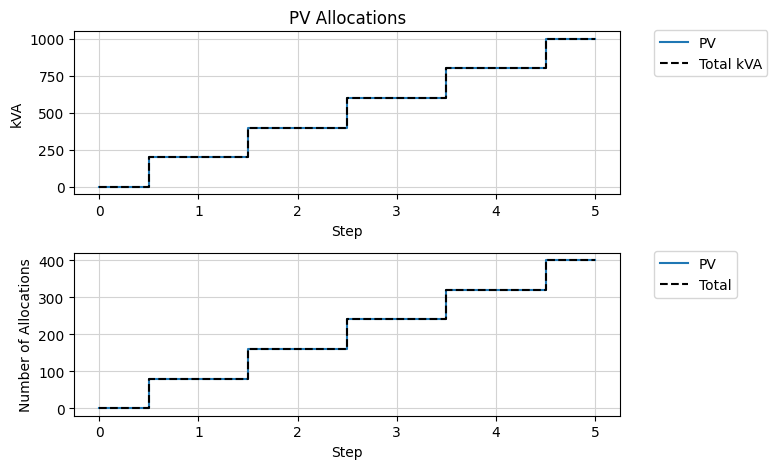

(<Figure size 640x480 with 2 Axes>,
 [<Axes: title={'center': 'PV Allocations'}, xlabel='Step', ylabel='kVA'>,
  <Axes: xlabel='Step', ylabel='Number of Allocations'>])

In [20]:
# to ensure propoper allocation
qsts_scenario.seed_results[0].plot(kind='pv_allocation')

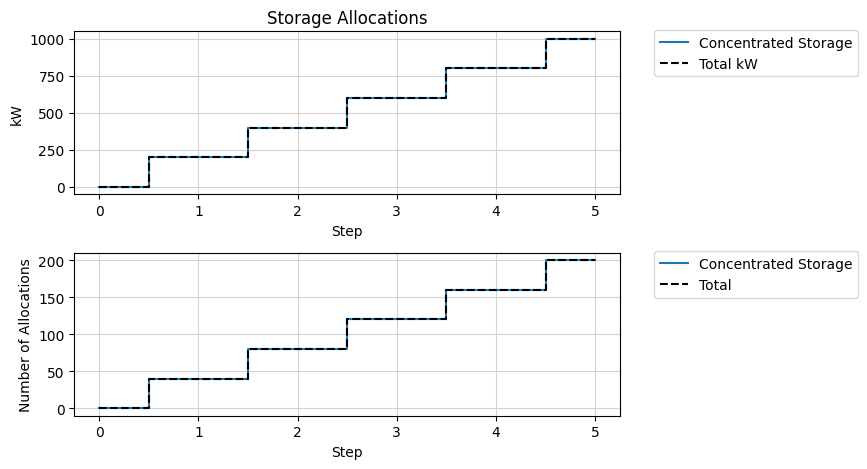

(<Figure size 640x480 with 2 Axes>,
 [<Axes: title={'center': 'Storage Allocations'}, xlabel='Step', ylabel='kW'>,
  <Axes: xlabel='Step', ylabel='Number of Allocations'>])

In [21]:
# to ensure propper allocation
qsts_scenario.seed_results[0].plot(kind='storage_allocation')

# TODO Modify for single ax, update labels.

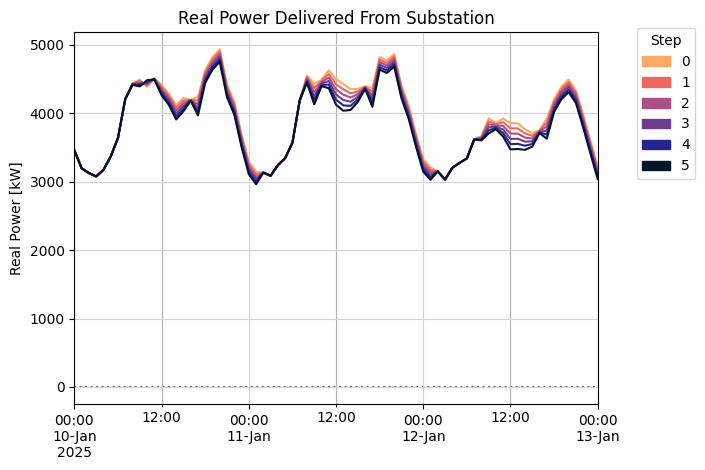

In [22]:
fig, ax = qsts_scenario.seed_results[0].plot(kind='p', use_dt=True)



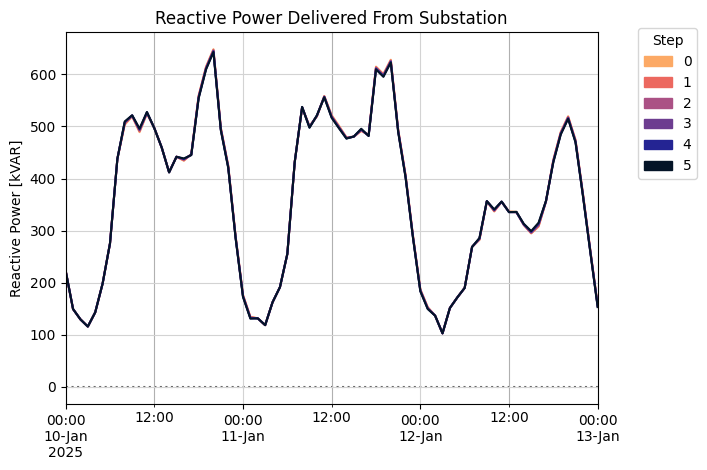

In [23]:
fig, ax = qsts_scenario.seed_results[0].plot(kind='q', use_dt=True)

Text(0.5, 1.0, 'Primary Maximum and Minimum Voltages')

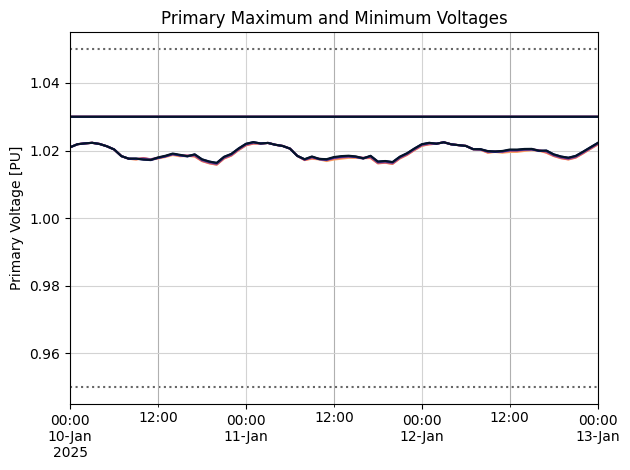

In [24]:
fig, ax = qsts_scenario.seed_results[0].plot(kind='voltage', use_dt=True, legend=False)
ax.set_title('Primary Maximum and Minimum Voltages')

Text(0.5, 1.0, 'Secondary Maximum and Minimum Voltages')

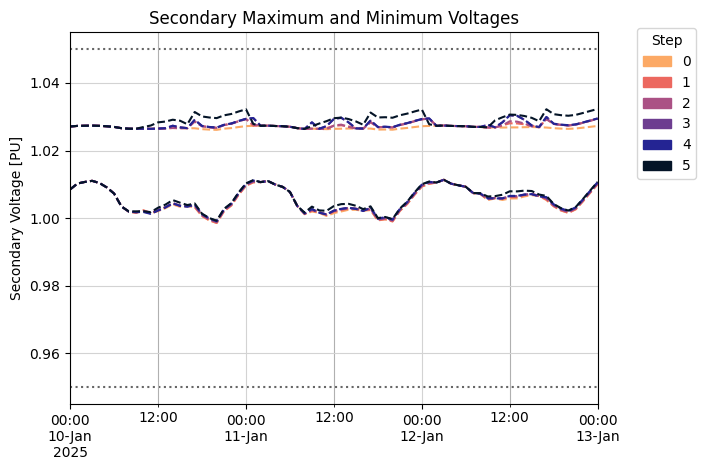

In [25]:
fig, ax = qsts_scenario.seed_results[0].plot(kind='voltage', use_dt=True, primary=False, legend=True)
ax.set_title('Secondary Maximum and Minimum Voltages')

Text(0.5, 1.0, 'Maximum Used Capacity of System Lines\n(dashed=secondary)')

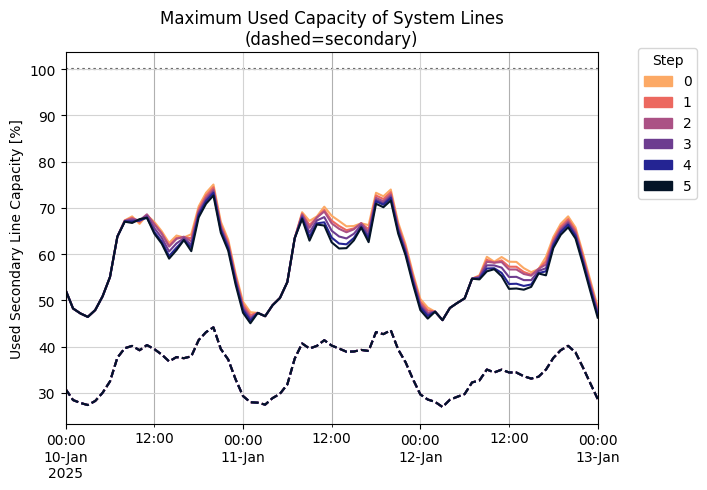

<Figure size 640x480 with 0 Axes>

In [26]:
fig, ax = qsts_scenario.seed_results[0].plot(kind='line', primary=True, use_dt=True)
qsts_scenario.seed_results[0].plot(kind='line', primary=False, legend=True, use_dt=True, ax=ax)
ax.set_title('Maximum Used Capacity of System Lines\n(dashed=secondary)')

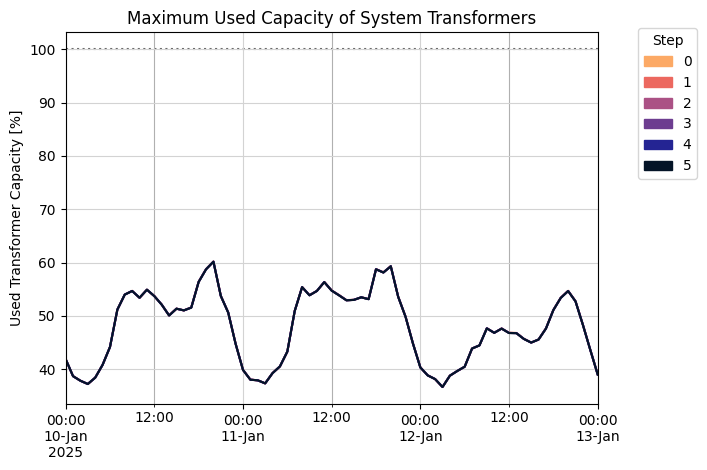

In [27]:
fig, ax = qsts_scenario.seed_results[0].plot(kind='transformer', use_dt=True)

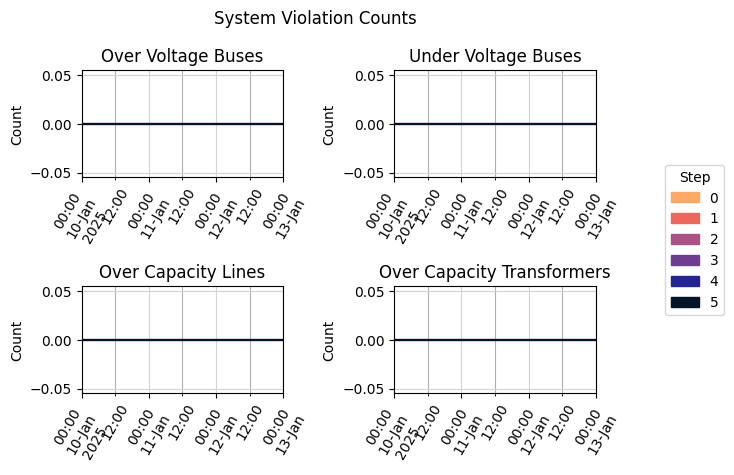

In [28]:
fig, axes = qsts_scenario.seed_results[0].plot(kind='violations', use_dt=True, as_percent=False)

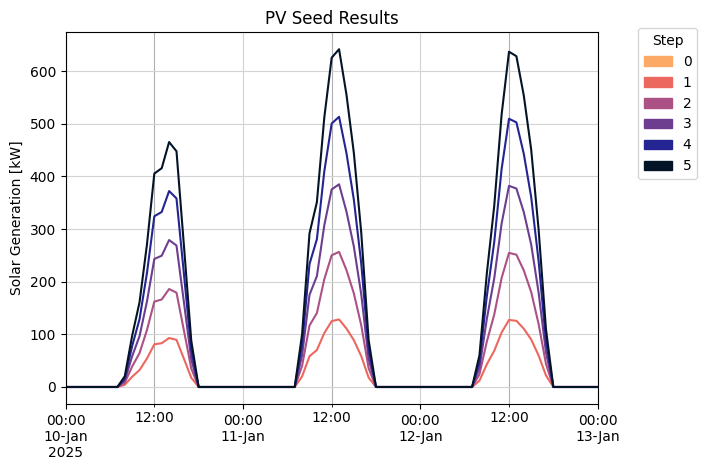

In [29]:
fig, ax = qsts_scenario.seed_results[0].plot(kind='pv_p', use_dt=True, legend_outside=True)


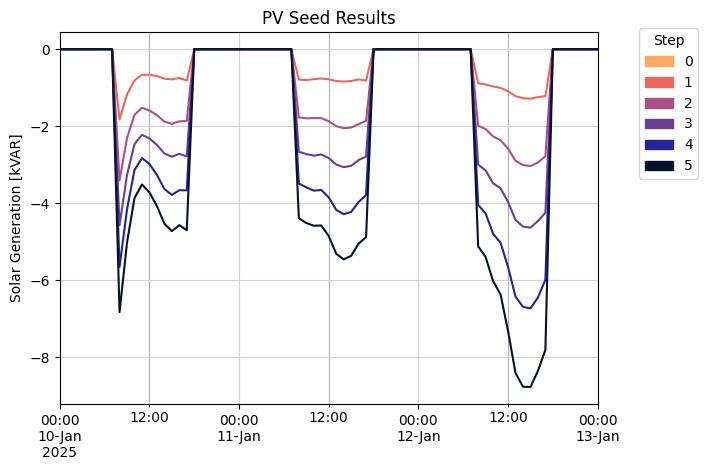

In [30]:
fig, ax = qsts_scenario.seed_results[0].plot(kind='pv_q', use_dt=True, legend_outside=True)

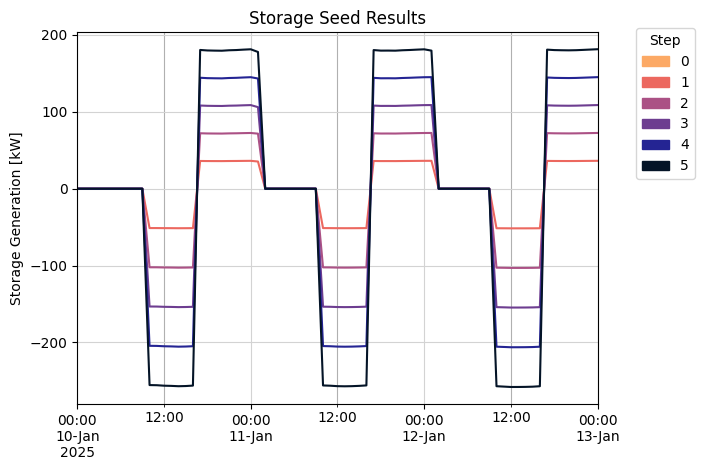

In [31]:
fig, ax = qsts_scenario.seed_results[0].plot(kind='storage_p', use_dt=True, legend_outside=True)

The above shows the step like behavior of the time control both charging and discharging

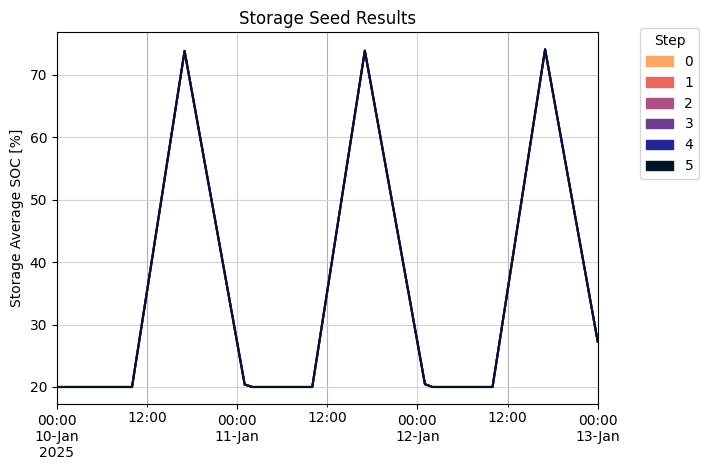

In [32]:
fig, ax = qsts_scenario.seed_results[0].plot(kind='storage_soc', use_dt=True, legend_outside=True)

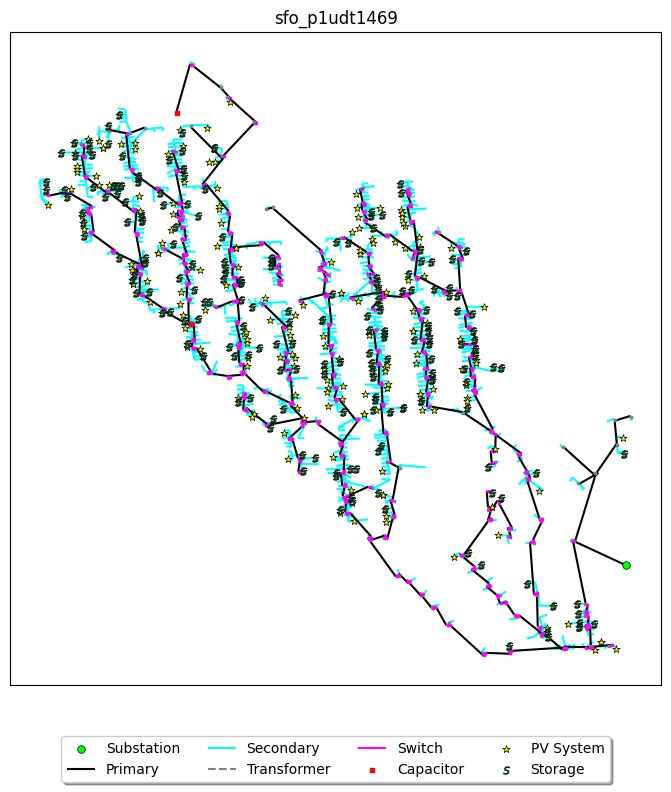

(<Figure size 1100x800 with 1 Axes>, <Axes: title={'center': 'sfo_p1udt1469'}>)

In [33]:
feeder.plot(kind='topo')